In [1]:
import numpy as np
from matplotlib import pyplot as plt

from pyloki.config import ParamLimits, PulsarSearchConfig
from pyloki.detection import thresholding
from pyloki.ffa import DynamicProgramming
from pyloki.periodogram import PruningStatsPlotter, ScatteredPeriodogram
from pyloki.prune import prune_dyp_tree
from pyloki.simulation.pulse import PulseSignalConfig

tobs = 2147.483648


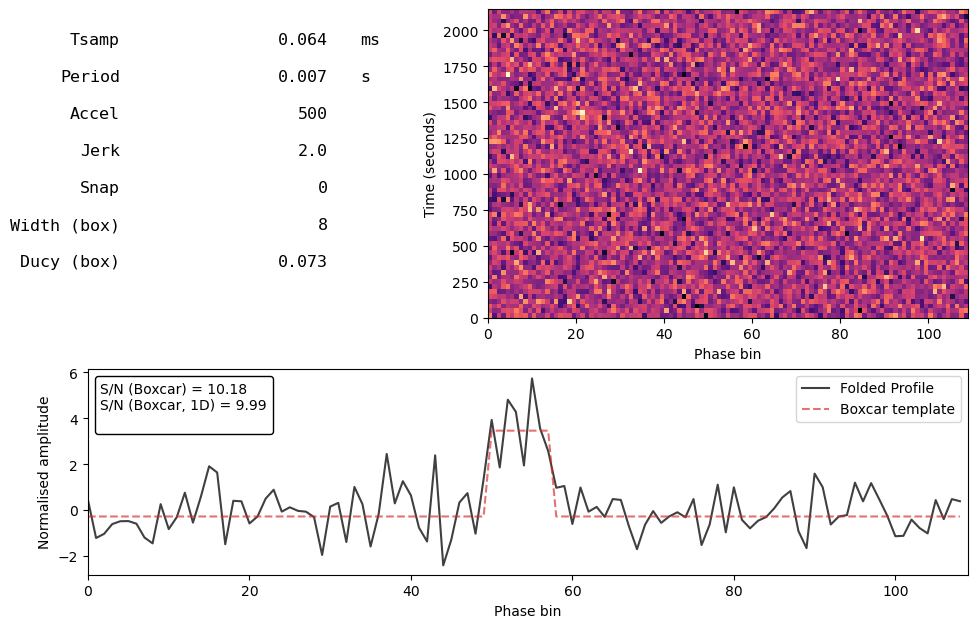

In [2]:
pulsar_period = 0.007
dt = 64e-6
accel = 500
jerk = 2.0
nsamps = 2**25
mod_kwargs = {"acc": accel, "jerk": jerk}
cfg = PulseSignalConfig(
    period=pulsar_period,
    dt=dt,
    nsamps=nsamps,
    snr=10.0,
    ducy=0.1,
    mod_kwargs=mod_kwargs,
)
print(f"tobs = {cfg.tobs}")
tim_data = cfg.generate(shape="gaussian")
tim_data.plot_fold(cfg.freq, cfg.fold_bins, mod_kwargs=mod_kwargs)
plt.show()

In [3]:
eta = 1
nbins = 64
p = ParamLimits.from_upper((142.0, 144.0), [jerk, accel], (-2.5, 2.5), cfg.tobs)
print(f"Param limits: {p.limits}")
bseg_brute = cfg.nsamps // 8192
bseg_ffa = cfg.nsamps // 128

search_cfg = PulsarSearchConfig(
    nsamps=cfg.nsamps,
    tsamp=cfg.dt,
    nbins=nbins,
    eta=eta,
    param_limits=p.limits,
    bseg_brute=bseg_brute,
    bseg_ffa=bseg_ffa,
    prune_poly_order=3,
    ducy_max=0.5,
    wtsp=1.2,
    use_fourier=True,
    use_conservative_tile=False,
    branch_max=32,
)
dyp = DynamicProgramming(tim_data, search_cfg)
dyp.initialize()
dyp.execute()

Param limits: [[-2.50000000e+00  2.50000000e+00]
 [-2.18435456e+03  3.18435456e+03]
 [ 1.41063088e+02  1.44950108e+02]]


2026-04-26 07:57:18 INFO     - pyloki.ffa - FFA initialize: Grid sizes: [3.44432122e+08 7.52423452e+06             
                             1.19209290e-01]

                    INFO     - pyloki.ffa - ffa level:  0, leaves: 5.04, fold dims: (8192, 1, 1, 33, 2, 33)

                    INFO     - pyloki.ffa - ffa_initialize finished, Elapsed time: 0.473 seconds

Output()

...

                    INFO     - pyloki.ffa - ffa level:  4, leaves:  9.03, fold dims: (512, 1, 1, 522, 2, 33)

                    INFO     - pyloki.ffa - ffa level:  5, leaves: 10.03, fold dims: (256, 1, 1, 1044, 2, 33)

                    INFO     - pyloki.ffa - ffa level:  6, leaves: 12.61, fold dims: (128, 1, 3, 2087, 2, 33)

                    INFO     - pyloki.ffa - FFA complete: Grid sizes: [1.31390428e+03 1.83697132e+03               
                             1.86264515e-03]

                    INFO     - pyloki.ffa - ffa_execute finished, Elapsed time: 3.670 seconds

In [4]:
branching_pattern = search_cfg.generate_branching_pattern(kind="poly_taylor_moving", ref_seg=64)
branching_pattern

array([4.        , 9.        , 1.        , 2.08672736, 1.43765786,
       3.        , 1.        , 9.        , 1.        , 1.        ,
       3.        , 1.        , 1.        , 2.08672736, 1.43765786,
       3.        , 1.        , 3.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 3.        , 2.19549593,
       1.36621563, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.53003195, 1.96074337,
       1.00063898, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 2.0862069 , 1.43709826,
       1.        , 1.        , 1.        , 1.        , 3.        ,
       1.        , 1.        , 1.        , 3.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.00063898, 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 2.12739464, 1.4101756 , 1.        , 1.     

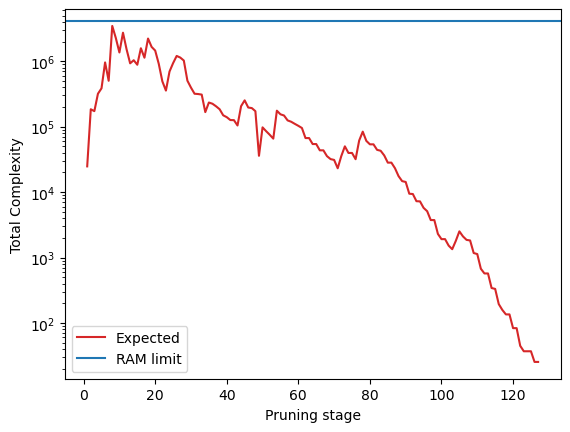

Branching Pattern: [4.0,9.0,1.0,2.1,1.4,3.0,1.0,9.0,1.0,1.0,3.0,1.0,1.0,2.1,1.4,3.0,1.0,3.0,
 1.0,1.0,1.0,1.0,1.0,3.0,2.2,1.4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.5,2.0,1.0,
 1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.1,1.4,1.0,1.0,1.0,1.0,3.0,1.0,1.0,1.0,3.0,
 1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.1,
 1.4,1.0,1.0,1.0,2.2,1.4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,
 1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.5,2.0,1.0,1.0,1.0,
 1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,
 1.0]

Thresholds: [1.9,2.3,2.2,2.3,2.4,2.5,2.9,2.9,3.1,3.3,3.4,3.6,3.7,3.9,4.0,4.1,4.1,4.2,
 4.2,4.1,4.3,4.5,4.5,4.6,4.7,4.5,4.4,4.4,4.8,4.8,4.8,4.5,4.4,5.1,5.1,4.9,
 4.9,4.9,5.0,4.9,4.9,4.6,4.9,4.8,4.9,5.0,4.8,4.9,5.6,5.5,5.5,5.5,5.5,5.5,
 5.5,5.4,5.5,5.4,5.4,5.4,5.4,5.6,4.9,5.6,5.2,5.6,4.9,5.6,5.6,5.5,5.7,5.8,
 5.2,5.8,5.1,5.8,5.8,5.3,5.9,5.9,5.4,5.9,5.8,5.9,6.0,5.3,6.0,6.1,6.1,6.0,
 6.2,6.0,6.2,6.0,6.2,6.2,6.3,5.9,6.4,6.4,5.8,6.4,6.4,6.4,6.5,6.5,6.5,6.4,
 6.6,6.5,6.7,6.7,6.1,6.8,6.7,6.9,6.9,6.9,6.3,7.0,6.5,7.1,7.1,6.4,6.6,7.1,
 6.4]

         Scheme Metrics Summary         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Metric                       ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ Branching mean               │  1.19 │
│ Branching max                │  9.00 │
│ Total enumerated options     │ 32.11 │
│ Pruning complexity           │ 13.10 │
│ Crude survival probability   │  0.08 │
│ Total cost                   │ 16.74 │
│ Number of independent trials │ 19.84 │
│ Total survival probability   │  0.81 │
└──────────────────────────────┴───────┘

In [6]:
thresholds = np.array([1.9, 2.3, 2.2, 2.3, 2.4, 2.5, 2.9, 2.9, 3.1, 3.3, 3.4, 3.6, 3.7,
       3.9, 4. , 4.1, 4.1, 4.2, 4.2, 4.1, 4.3, 4.5, 4.5, 4.6, 4.7, 4.5,
       4.4, 4.4, 4.8, 4.8, 4.8, 4.5, 4.4, 5.1, 5.1, 4.9, 4.9, 4.9, 5. ,
       4.9, 4.9, 4.6, 4.9, 4.8, 4.9, 5. , 4.8, 4.9, 5.6, 5.5, 5.5, 5.5,
       5.5, 5.5, 5.5, 5.4, 5.5, 5.4, 5.4, 5.4, 5.4, 5.6, 4.9, 5.6, 5.2,
       5.6, 4.9, 5.6, 5.6, 5.5, 5.7, 5.8, 5.2, 5.8, 5.1, 5.8, 5.8, 5.3,
       5.9, 5.9, 5.4, 5.9, 5.8, 5.9, 6. , 5.3, 6. , 6.1, 6.1, 6. , 6.2,
       6. , 6.2, 6. , 6.2, 6.2, 6.3, 5.9, 6.4, 6.4, 5.8, 6.4, 6.4, 6.4,
       6.5, 6.5, 6.5, 6.4, 6.6, 6.5, 6.7, 6.7, 6.1, 6.8, 6.7, 6.9, 6.9,
       6.9, 6.3, 7. , 6.5, 7.1, 7.1, 6.4, 6.6, 7.1, 6.4])
thresh_state = thresholding.evaluate_scheme(
    thresholds,
    branching_pattern,
    ref_ducy=0.1,
    nbins=64,
    ntrials=1024,
    snr_final=9.0,
    ducy_max=0.5,
    wtsp=1.2,
)
x = np.arange(1, len(branching_pattern) + 1)
plt.semilogy(
    x,
    np.array(thresh_state.get_info("complexity")) * dyp.nparam_vol,
    label="Expected",
    c="tab:red",
)
plt.axhline(2**22, label="RAM limit", c="tab:blue")
plt.xlabel("Pruning stage")
plt.ylabel("Total Complexity")
plt.legend()
plt.show()
thresh_state.print_summary()

In [11]:
result_file = prune_dyp_tree(
    dyp,
    thresholds,
    n_runs=16,
    max_sugg=2**22,
    outdir="pruning_results/jerk_test/",
    file_prefix="test_jerk",
    poly_basis="taylor",
    n_workers=4,
    use_moving_grid=True,
)

2026-04-25 14:37:14 INFO     - pyloki.prune - Starting Pruning for 16 runs, with 4 workers

Output()

2026-04-25 14:43:00 INFO     - pyloki.prune - Pruning complete. Results saved to                                   
                             pruning_results/jerk_test/test_jerk_pruning_nstages_128_results.h5

In [18]:
pgram = ScatteredPeriodogram.load(result_file)
print(f"True params, j: {cfg.mod_kwargs["jerk"]:.3f}, a: {cfg.mod_kwargs["acc"]:.3f}, f: {cfg.freq:.10f}")
print(pgram.get_summary_cands(10, score_type="score", run_id=None))

True params, j: 2.000, a: 500.000, f: 142.8571428571
Top candidates:
dparams: djerk: 0.0007579657396, daccel: 0.2034650488, dfreq: 2.299372669e-05
Run: 067_09, S/N (EP): 7.36, S/N: 8.13, jerk: -2.46009, accel: -122.20, freq: 143.278147
Run: 028_04, S/N (EP): 7.68, S/N: 7.90, jerk: -1.18370, accel: 1354.71, freq: 141.634264
Run: 099_13, S/N (EP): 7.99, S/N: 7.76, jerk: 1.98240, accel: -1229.11, freq: 141.087826
Run: 028_04, S/N (EP): 7.66, S/N: 7.76, jerk: -1.18370, accel: 1354.50, freq: 141.634258
Run: 067_09, S/N (EP): 7.49, S/N: 7.75, jerk: -2.46009, accel: -122.40, freq: 143.278141
Run: 067_09, S/N (EP): 7.39, S/N: 7.75, jerk: -2.46009, accel: -122.60, freq: 143.278135
Run: 067_09, S/N (EP): 7.28, S/N: 7.73, jerk: -2.46009, accel: -122.40, freq: 143.278164
Run: 067_09, S/N (EP): 7.37, S/N: 7.69, jerk: -2.46009, accel: -122.60, freq: 143.278158
Run: 067_09, S/N (EP): 7.46, S/N: 7.65, jerk: -2.45857, accel: -122.23, freq: 143.278191
Run: 115_15, S/N (EP): 7.63, S/N: 7.65, jerk: -2.216

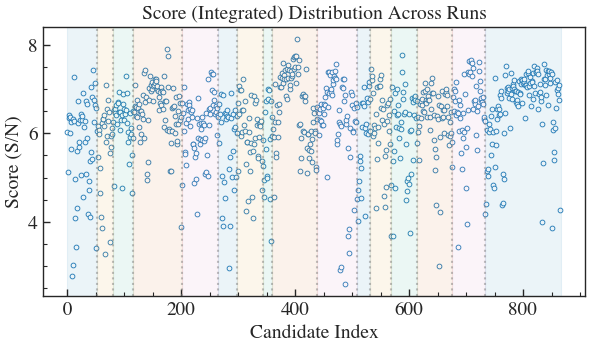

In [13]:
pgram.plot_scores(kind="scatter", score_type="score", run_id=None)
plt.show()

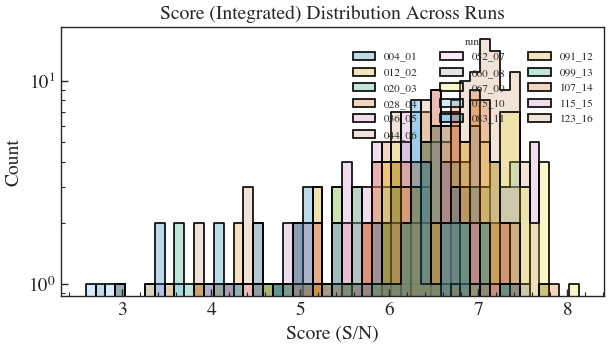

In [14]:
pgram.plot_scores(kind="hist", run_id=None)
plt.show()

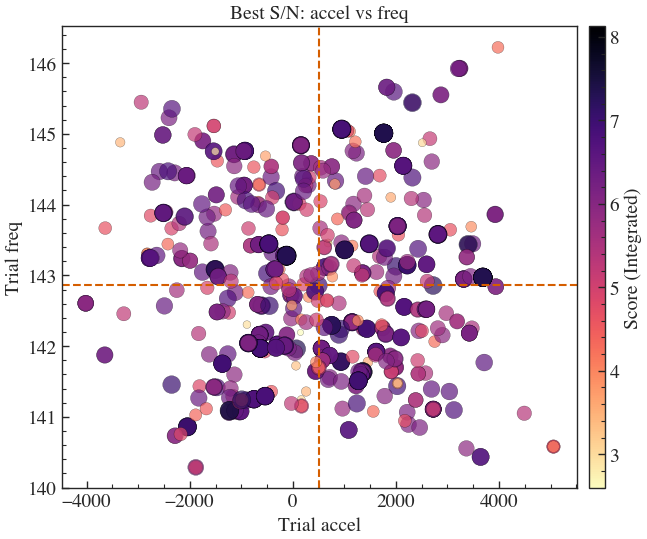

In [15]:
pgram.plot_correlation("accel", "freq", true_values={"accel": cfg.mod_kwargs["acc"], "freq": cfg.freq}, run_id=None)
plt.show()

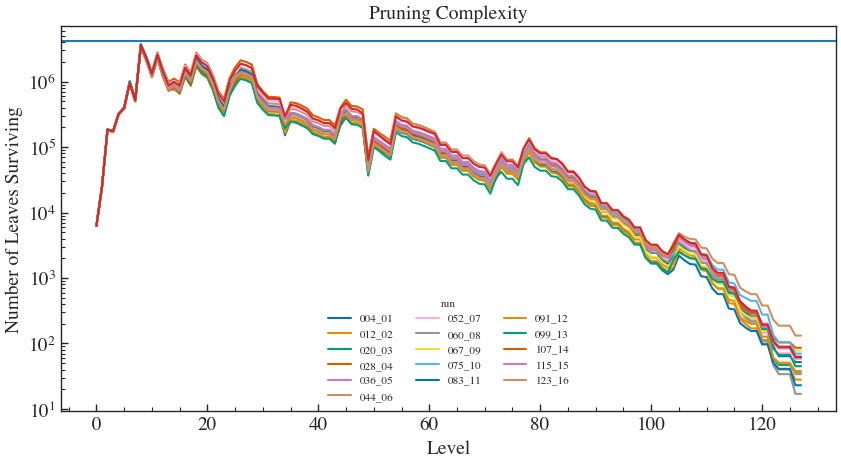

In [16]:
pstats = PruningStatsPlotter.load(result_file)
fig = pstats.plot_level_stats(run_id=None)
x = np.arange(0, len(branching_pattern) + 1)
ax_list = fig.axes
ax_list[0].plot(x, np.concatenate(([1], thresh_state.get_info("complexity"))) * dyp.nparam_vol, label="Expected", c="tab:red")
ax_list[0].axhline(2**22, label="RAM limit", c="tab:blue")
plt.show()